In [1]:
from datasets import load_dataset, ClassLabel

ds = load_dataset("matthieulel/galaxy10_decals")

# Infer #classes and cast
labels = ds["train"]["label"]
n_classes = int(max(labels)) + 1
ds = ds.cast_column("label", ClassLabel(num_classes=n_classes))

# Now stratified split works
split_ds = ds["train"].train_test_split(test_size=0.2, seed=42,
                                        stratify_by_column="label")
train_ds = split_ds["train"]
val_ds   = split_ds["test"]


In [2]:
import timm
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt = torch.load("./checkpoints_vit_s/checkpoint_0300.pth.tar", map_location="cpu")
print(ckpt.keys())


dict_keys(['epoch', 'arch', 'state_dict', 'optimizer', 'scaler'])


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm

# -------------------------
# Encoder factory (no pretrained weights)
# -------------------------
def build_encoder(arch: str):
    """
    Returns (model, is_vit).
    - torchvision ResNets: 'resnet18', 'resnet34', 'resnet50', 'resnet101', ...
    - timm ViTs: 'vit_small_patch16_224', 'vit_base_patch16_224', ...
    """
    arch = arch.lower()
    
    # make sure arch in resnet18, resnet50, vit_s, vit_b
    assert arch in ['resnet18', 'resnet34', 'resnet50', 'resnet101',
                    'vit_s', 'vit_b'], f"Unknown architecture '{arch}'"
    
    if arch == 'vit_s':
        arch = 'vit_small_patch16_224'
    elif arch == 'vit_b':
        arch = 'vit_base_patch16_224'

    # Prefer timm if the name matches a timm model (covers ViT small/base cleanly)
    if arch in timm.list_models():
        # num_classes=0 => remove classifier; forward returns features
        model = timm.create_model(arch, pretrained=False, num_classes=0)
        # Heuristic: ViTs in timm have .patch_embed and .blocks
        is_vit = hasattr(model, "patch_embed") and hasattr(model, "blocks") and ("vit" in arch)
        return model, is_vit

def model_feature_dim(model) -> int:
    """Robustly get the feature dimension after global pooling / CLS."""
    # timm models expose num_features reliably
    if hasattr(model, "num_features"):
        return int(model.num_features)

    # torchvision ResNet after replacing fc with Identity -> in_features is lost,
    # so we infer by a quick forward on a dummy input (safe + cheap).
    # Use a small 224x224 RGB; adjust if your input size differs.
    with torch.no_grad():
        model.eval()
        x = torch.zeros(1, 3, 224, 224)
        y = model(x)
        return int(y.shape[-1])

class MoCo(nn.Module):
    """
    Generic MoCo-style (symmetric) with:
      - a base encoder (query) and a momentum encoder (key)
      - MLP projector on top of encoder outputs
      - MLP predictor on top of projector
    Uses an in-batch contrastive loss (no queue) for simplicity.
    """

    def __init__(
        self,
        encoder_name: str,
        dim: int = 256,
        mlp_dim: int = 4096,
        T: float = 0.2,
        proj_layers: int = 3,     # 2 for ResNet-like, 3 sometimes used for ViT
        pred_layers: int = 2,
    ):
        """
        encoder_name: string name for the base encoder
        dim:         projector output dimension
        mlp_dim:     hidden dimension for MLPs
        T:           softmax temperature
        proj_layers: number of layers in projector MLP
        pred_layers: number of layers in predictor MLP
        """
        super().__init__()
        self.T = T

        # Build encoders (no pretrained weights)
        q_enc, is_vit_q = build_encoder(encoder_name)
        k_enc, is_vit_k = build_encoder(encoder_name)
        assert is_vit_q == is_vit_k, "Query and key encoder types must match"

        self.base_encoder = q_enc
        self.momentum_encoder = k_enc
        self.is_vit = is_vit_q

        feat_dim = model_feature_dim(self.base_encoder)

        # Projectors (on top of encoder outputs)
        self.projector_q = self._build_mlp(
            num_layers=proj_layers, input_dim=feat_dim, mlp_dim=mlp_dim, output_dim=dim,
            last_bn=True
        )
        self.projector_k = self._build_mlp(
            num_layers=proj_layers, input_dim=feat_dim, mlp_dim=mlp_dim, output_dim=dim,
            last_bn=True
        )

        # Predictor
        self.predictor = self._build_mlp(
            num_layers=pred_layers, input_dim=dim, mlp_dim=mlp_dim, output_dim=dim, 
            last_bn=False
        )

        # Initialize momentum encoder weights
        for pb, pm in zip(self.base_encoder.parameters(), self.momentum_encoder.parameters()):
            pm.data.copy_(pb.data)
            pm.requires_grad = False

        for pb, pm in zip(self.projector_q.parameters(), self.projector_k.parameters()):
            pm.data.copy_(pb.data)
            pm.requires_grad = False

    def _build_mlp(self, num_layers, input_dim, mlp_dim, output_dim, last_bn=True):
        layers = []
        for l in range(num_layers):
            in_d = input_dim if l == 0 else mlp_dim
            out_d = output_dim if l == num_layers - 1 else mlp_dim
            layers.append(nn.Linear(in_d, out_d, bias=False))
            if l < num_layers - 1:
                layers.append(nn.BatchNorm1d(out_d))
                layers.append(nn.ReLU(inplace=True))
            elif last_bn:
                # SimCLR-style last BN without affine
                layers.append(nn.BatchNorm1d(out_d, affine=False))
        return nn.Sequential(*layers)

    @torch.no_grad()
    def _update_momentum(self, m: float):
        """Momentum update for encoder and projector_k."""
        for pb, pm in zip(self.base_encoder.parameters(), self.momentum_encoder.parameters()):
            pm.data.mul_(m).add_(pb.data, alpha=1.0 - m)
        for pb, pm in zip(self.projector_q.parameters(), self.projector_k.parameters()):
            pm.data.mul_(m).add_(pb.data, alpha=1.0 - m)

    def _encode(self, encoder, projector, x: torch.Tensor) -> torch.Tensor:
        """
        Encodes images to projector space (no predictor here).
        Output shape: [N, dim]
        """
        z = encoder(x)          # features
        if z.ndim > 2:
            z = z.view(z.size(0), -1)
        z = projector(z)
        return z

    def contrastive_loss(self, q: torch.Tensor, k: torch.Tensor) -> torch.Tensor:
        # normalize
        q = F.normalize(q, dim=1)
        k = F.normalize(k, dim=1)

        # similarity matrix [N, N]
        logits = torch.einsum("nc,mc->nm", q, k) / self.T

        N = logits.size(0)
        device = logits.device
        labels = torch.arange(N, device=device, dtype=torch.long)

        loss = F.cross_entropy(logits, labels)
        return loss * (2 * self.T)

    def forward(self, x1: torch.Tensor, x2: torch.Tensor, m: float):
        """
        x1, x2: two augmented views
        m: momentum coefficient for the EMA update
        """
        # query branch with predictor
        z1_q = self._encode(self.base_encoder, self.projector_q, x1)
        z2_q = self._encode(self.base_encoder, self.projector_q, x2)
        q1 = self.predictor(z1_q)
        q2 = self.predictor(z2_q)

        with torch.no_grad():
            self._update_momentum(m)
            k1 = self._encode(self.momentum_encoder, self.projector_k, x1)
            k2 = self._encode(self.momentum_encoder, self.projector_k, x2)

        return self.contrastive_loss(q1, k2) + self.contrastive_loss(q2, k1)

In [4]:
arch = 'vit_s'
moco_t = .2
moco_dim = 256
moco_mlp_dim = 4096

model = MoCo(
    encoder_name=arch,
    dim=moco_dim,
    mlp_dim=moco_mlp_dim,
    T=moco_t,
    proj_layers=3 if 'vit' in arch else 2,
    pred_layers=2,
)


In [5]:
model.load_state_dict(ckpt["state_dict"], strict=True)

<All keys matched successfully>

In [6]:
feature_extractor = model.base_encoder

In [7]:
for p in feature_extractor.parameters():
    p.requires_grad = False
feature_extractor.eval()

import torch
import torch.nn as nn
import torch.nn.functional as F
import timm

class Classifier(nn.Module):
    def __init__(self, backbone, num_classes=10):
        super(Classifier, self).__init__()
        self.backbone = backbone
        self.fc = nn.Linear(backbone.num_features, num_classes)

    def forward(self, x):
        x = self.backbone(x)
        x = self.fc(x)
        return x

x = torch.randn(2, 3, 224, 224)
test_model = Classifier(feature_extractor).to(device)
test_model.eval()
with torch.no_grad():
    y = test_model(x.to(device))
print(y.shape)  # torch.Size([2, 10])

torch.Size([2, 10])


torch.Size([512, 3, 224, 224]) torch.Size([512])


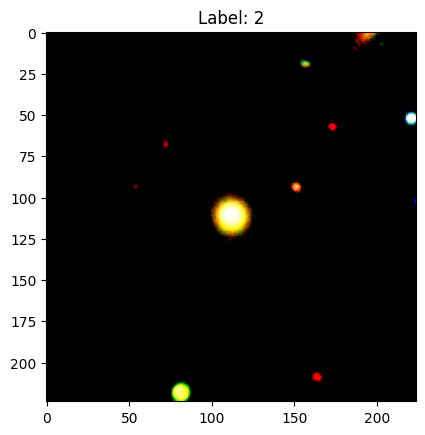

In [ ]:
# design training script
# 1. construct dataloader
from torch.utils.data import DataLoader
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def apply_transforms(batch): 
    x_list = []
    for img in batch["image"]: 
        x = transform(img) 
        x_list.append(x) 

    batch = {"image": torch.stack(x_list), "label": batch["label"]}
    return batch 

def collate_fn(batch): 
    x = torch.stack([b["image"] for b in batch]) 
    y  = torch.tensor([b["label"] for b in batch], dtype=torch.long)
    return x, y

train_dataset = train_ds.with_transform(apply_transforms)
val_dataset   = val_ds.with_transform(apply_transforms)

batch_size = 512
workers = 32

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size, shuffle=True,
    num_workers=workers, pin_memory=True, drop_last=True,
    collate_fn=collate_fn,
)
val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size, shuffle=False,
    num_workers=workers, pin_memory=True, drop_last=False,
    collate_fn=collate_fn,
)

import matplotlib.pyplot as plt
import numpy as np

for x, y in val_loader:
    print(x.shape, y.shape)  # torch.Size([512, 3, 224, 224]) torch.Size([512])
    # show the first x and first y
    img = x[0].numpy().transpose(1, 2, 0)
    fig = plt.figure()
    plt.imshow(np.clip(img, 0, 1))
    plt.title(f"Label: {y[0].item()}")
    plt.axis('off')
    plt.show()
    break

In [9]:
import os, csv, time, math, random
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim

# -------------------------
# Repro
# -------------------------
def set_seed(seed: int = 42):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# -------------------------
# Metrics
# -------------------------
@torch.no_grad()
def accuracy(logits: torch.Tensor, targets: torch.Tensor) -> float:
    preds = logits.argmax(dim=1)
    return (preds == targets).float().mean().item()

# -------------------------
# Train / Val loops
# -------------------------
def train_one_epoch(model, loader, optimizer, criterion, device, scaler=None):
    model.train()
    running_loss = 0.0
    n = 0
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        if scaler is not None:
            with torch.amp.autocast(device_type=device.type):
                logits = model(images)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        n += batch_size

    return running_loss / max(n, 1)

@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss, total_acc, n = 0.0, 0.0, 0
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(images)
        loss = criterion(logits, labels)

        bs = labels.size(0)
        total_loss += loss.item() * bs
        total_acc  += accuracy(logits, labels) * bs
        n += bs

    return total_loss / max(n, 1), total_acc / max(n, 1)

# -------------------------
# Main
# -------------------------
num_classes=10
epochs=100
lr=3e-4
wd=1e-4
out_dir="runs/exp1"
use_amp=True
seed=42
backbone = feature_extractor  # from pre-trained MoCo

set_seed(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
out = Path(out_dir); out.mkdir(parents=True, exist_ok=True)

# Model / Loss / Optimizer
model = Classifier(backbone=backbone, num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
scaler = torch.amp.GradScaler() if (use_amp and device.type == "cuda") else None

# Optional cosine LR (flat start, cosine decay)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

# Metrics log
metrics_csv = out / "metrics.csv"
with metrics_csv.open("w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["epoch", "lr", "train_loss", "val_loss", "val_acc"])

best_val_acc = -1.0
best_path = out / "best.ckpt"
last_path = out / "last.ckpt"

for epoch in range(1, epochs + 1):
    t0 = time.time()
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device, scaler)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    scheduler.step()

    lr_now = optimizer.param_groups[0]["lr"]
    dt = time.time() - t0

    # Log
    print(f"Epoch {epoch:03d}/{epochs} | "
            f"lr {lr_now:.2e} | "
            f"train_loss {train_loss:.4f} | "
            f"val_loss {val_loss:.4f} | "
            f"val_acc {val_acc*100:.2f}% | "
            f"{dt:.1f}s")

    with metrics_csv.open("a", newline="") as f:
        csv.writer(f).writerow([epoch, lr_now, train_loss, val_loss, val_acc])

    # # Checkpointing
    # torch.save({"epoch": epoch,
    #             "model": model.state_dict(),
    #             "optimizer": optimizer.state_dict(),
    #             "scaler": scaler.state_dict() if scaler else None},
    #            last_path)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        # torch.save({"epoch": epoch,
        #             "model": model.state_dict(),
        #             "optimizer": optimizer.state_dict(),
        #             "scaler": scaler.state_dict() if scaler else None},
        #            best_path)

print(f"Done. Best val_acc: {best_val_acc*100:.2f}% | saved -> {best_path}")

Epoch 001/100 | lr 3.00e-04 | train_loss 2.1254 | val_loss 1.9647 | val_acc 34.42% | 57.3s
Epoch 002/100 | lr 3.00e-04 | train_loss 1.8445 | val_loss 1.7366 | val_acc 46.66% | 33.5s
Epoch 003/100 | lr 2.99e-04 | train_loss 1.6425 | val_loss 1.5717 | val_acc 53.24% | 37.6s
Epoch 004/100 | lr 2.99e-04 | train_loss 1.4981 | val_loss 1.4505 | val_acc 55.97% | 34.0s
Epoch 005/100 | lr 2.98e-04 | train_loss 1.3908 | val_loss 1.3606 | val_acc 59.00% | 34.1s
Epoch 006/100 | lr 2.97e-04 | train_loss 1.3087 | val_loss 1.2925 | val_acc 61.13% | 53.9s
Epoch 007/100 | lr 2.96e-04 | train_loss 1.2436 | val_loss 1.2369 | val_acc 62.14% | 32.4s
Epoch 008/100 | lr 2.95e-04 | train_loss 1.1930 | val_loss 1.1937 | val_acc 62.89% | 42.8s
Epoch 009/100 | lr 2.94e-04 | train_loss 1.1523 | val_loss 1.1579 | val_acc 63.86% | 32.7s
Epoch 010/100 | lr 2.93e-04 | train_loss 1.1190 | val_loss 1.1288 | val_acc 64.61% | 33.8s
Epoch 011/100 | lr 2.91e-04 | train_loss 1.0901 | val_loss 1.1037 | val_acc 65.30% | 36.5s

In [ ]:
test_ds  = ds["test"]
test_dataset = test_ds.with_transform(apply_transforms)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size, shuffle=False,
    num_workers=workers, pin_memory=True, drop_last=False,
    collate_fn=collate_fn
)

test_loss, test_acc = validate(model, test_loader, criterion, device)
print(f"Test loss {test_loss:.4f} | Test acc {test_acc*100:.2f}%")
